In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt

C:\Users\jingl\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
# Data import
df = pd.read_csv("AirQualityData.csv")
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
df.set_index('Datetime', inplace=True)

In [5]:
# Apply IQR , then Clean and Smooth temperature
q1 = df['Temperature'].quantile(0.25)
q3 = df['Temperature'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

df['Temperature_cleaned'] = df['Temperature'].where(
    (df['Temperature'] >= lower_bound) & (df['Temperature'] <= upper_bound), np.nan
)
print("Missing values after IQR filter:", df['Temperature_cleaned'].isna().sum())
df['Temperature_cleaned'] = df['Temperature_cleaned'].interpolate(method='time')
df['Temperature_smooth'] = df['Temperature_cleaned'].rolling(window=5, center=True).mean()

Missing values after IQR filter: 0


In [6]:
# Resample after smoothing 
df_daily = df[['Temperature_smooth']].resample('D').mean().dropna()
df_daily = df_daily.rename(columns={'Temperature_smooth': 'y'})

# Apply log transformation AFTER df_daily is defined
df_daily['y'] = np.log1p(df_daily['y'])

In [7]:
df_prophet = df_daily.reset_index().rename(columns={'Datetime': 'ds'})
split = int(len(df_prophet) * 0.8)
train_p = df_prophet.iloc[:split]
test_p = df_prophet.iloc[split:]

model_p = Prophet(seasonality_mode='multiplicative', daily_seasonality=True)
model_p.fit(train_p)

future = model_p.make_future_dataframe(periods=len(test_p), freq='D')
forecast = model_p.predict(future)

19:19:09 - cmdstanpy - INFO - Chain [1] start processing
19:19:09 - cmdstanpy - INFO - Chain [1] done processing


In [8]:
#  Combine forecast with residuals 
df_combined = df_prophet.copy()
df_combined['yhat'] = forecast['yhat'].values[:len(df_combined)]
df_combined['residual'] = df_combined['y'] - df_combined['yhat']
print("Available columns in df_daily:", df_daily.columns.tolist())

# Time-based features
df_combined['dayofweek'] = df_combined['ds'].dt.dayofweek
df_combined['month'] = df_combined['ds'].dt.month

Available columns in df_daily: ['y']


In [9]:
# Lag Features 
for lag in range(1, 8):
    df_combined[f'lag_{lag}'] = df_combined['residual'].shift(lag)

df_combined = df_combined.dropna(subset=[f'lag_{i}' for i in range(1, 8)] + ['dayofweek', 'month'])

In [10]:
# XGBoost Model Setup 
lag_cols = [f'lag_{i}' for i in range(1, 8)]
X = df_combined[lag_cols + ['dayofweek', 'month']]
y = df_combined['residual']

split2 = int(len(df_combined) * 0.8)
X_train = X.iloc[:split2]
y_train = y.iloc[:split2]
X_test = X.iloc[split2:]
y_test = y.iloc[split2:]
test_start_date = df_combined['ds'].iloc[split2]

In [11]:
# Grid Search setup
tscv = TimeSeriesSplit(n_splits=3)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

In [12]:
model = XGBRegressor(objective='reg:squarederror', random_state=42)
grid = GridSearchCV(model, param_grid, cv=tscv, scoring='r2', verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.7}


In [13]:
# Forescast training set
# Predict on Training Set 
residual_train_pred = best_model.predict(X_train)
final_forecast_train = df_combined.iloc[:split2]['yhat'].values + residual_train_pred
actual_train = df_combined.iloc[:split2]['y'].values

# Invert log transformation
final_forecast_train = np.expm1(final_forecast_train)
actual_train = np.expm1(actual_train)

# Store training predictions in df_combined
df_combined.loc[df_combined.index[:split2], 'final_forecast'] = final_forecast_train

In [14]:
# --- 8. Forecast Residuals + Final Forecast (Test Set)
residual_pred = best_model.predict(X_test)
final_forecast = df_combined.iloc[split2:]['yhat'].values + residual_pred
actual = df_combined.iloc[split2:]['y'].values

# Invert log transformation
final_forecast = np.expm1(final_forecast)
actual = np.expm1(actual)
df_combined.loc[df_combined.index[split2:], 'final_forecast'] = final_forecast

In [15]:
#  Evaluation Metrics (Test Set)
print("\nHybrid Prophet+XGBoost (Test Set): ")
print(f"MSE: {mean_squared_error(actual, final_forecast):.2f}")
print(f"RMSE: {mean_squared_error(actual, final_forecast, squared=False):.2f}")
print(f"MAE: {mean_absolute_error(actual, final_forecast):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(actual, final_forecast):.2f}")
print(f"R²: {r2_score(actual, final_forecast):.4f}")

#  Evaluation Metrics (Training Set)
print("\nHybrid Prophet+XGBoost (Training Set): ")
print(f"MSE: {mean_squared_error(actual_train, final_forecast_train):.2f}")
print(f"RMSE: {mean_squared_error(actual_train, final_forecast_train, squared=False):.2f}")
print(f"MAE: {mean_absolute_error(actual_train, final_forecast_train):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(actual_train, final_forecast_train):.2f}")
print(f"R²: {r2_score(actual_train, final_forecast_train):.4f}")


Hybrid Prophet+XGBoost (Test Set): 
MSE: 6.15
RMSE: 2.48
MAE: 1.98
MAPE: 0.12
R²: 0.0823

Hybrid Prophet+XGBoost (Training Set): 
MSE: 4.85
RMSE: 2.20
MAE: 1.74
MAPE: 0.10
R²: 0.2721


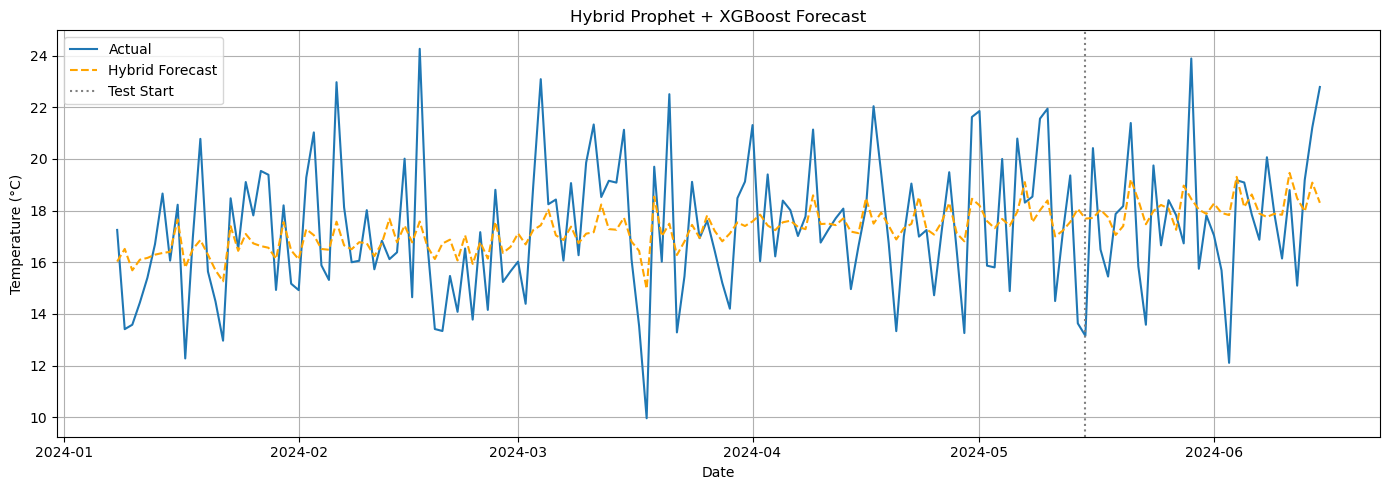

In [16]:
# --- 10. Plot Results ---
plt.figure(figsize=(14, 5))
plt.plot(df_combined['ds'], np.expm1(df_combined['y']), label='Actual')
plt.plot(df_combined['ds'], df_combined['final_forecast'], label='Hybrid Forecast', linestyle='--', color='orange')
plt.axvline(test_start_date, color='gray', linestyle=':', label='Test Start')
plt.title("Hybrid Prophet + XGBoost Forecast")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [28]:
yhat_test = df_combined.iloc[split2:]['yhat'].values
r2_prophet = r2_score(actual, yhat_test)
MSE = mean_squared_error(actual, yhat_test)
RMSE = mean_squared_error(actual, yhat_test, squared=False)
MAE = mean_absolute_error(actual, yhat_test)
MAPE = mean_absolute_percentage_error(actual, yhat_test)

print("Prophet R² alone:", r2_prophet)
print("Prophet MSE alone:", MSE)
print("Prophet RMSE alone: ", RMSE)
print("Prophet MAE alone: ", MAE)
print("Prophet MAPE alone: ", MAPE)

Prophet R² alone: -32.66667686120794
Prophet MSE alone: 225.7773858151014
Prophet RMSE alone:  15.02589051654182
Prophet MAE alone:  14.802261832082582
Prophet MAPE alone:  0.8301950027854568


In [30]:
model_xgb_y = XGBRegressor(n_estimators=100,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.7,
    colsample_bytree=0.8,)
model_xgb_y.fit(X_train, df_combined.iloc[:split2]['y'])

y_pred_y = model_xgb_y.predict(X_test)
print("R² (XGBoost directly on y):", r2_score(df_combined.iloc[split2:]['y'], y_pred_y))
print("MSE (XGBoost directly on y):", mean_squared_error(df_combined.iloc[split2:]['y'], y_pred_y))
print("RMSE (XGBoost directly on y):", mean_squared_error(df_combined.iloc[split2:]['y'], y_pred_y,squared = False))
print("MAE (XGBoost directly on y):", mean_absolute_error(df_combined.iloc[split2:]['y'], y_pred_y))
print("MAPE (XGBoost directly on y):", mean_absolute_percentage_error(df_combined.iloc[split2:]['y'], y_pred_y))

R² (XGBoost directly on y): 0.020213138811991493
MSE (XGBoost directly on y): 0.01923177307219931
RMSE (XGBoost directly on y): 0.13867866841082413
MAE (XGBoost directly on y): 0.11096134049769354
MAPE (XGBoost directly on y): 0.038117488711471595


In [19]:
# Time settings
# Create future dates starting after the last training date
last_train_date = df_prophet['ds'].max()
future_dates = pd.date_range(start=last_train_date + pd.Timedelta(days=1), periods=7, freq='D')
forecast_7 = pd.DataFrame({'ds': future_dates})

# Get data from 7 weeks (49 days) before June 15
cutoff_date = pd.to_datetime("2024-06-15")
past_7_weeks = df_combined[df_combined['ds'].between(cutoff_date - pd.Timedelta(weeks=7), cutoff_date - pd.Timedelta(days=1))].copy()

In [20]:
# Get Prophet forecast for these future dates
prophet_preds = model_p.predict(forecast_7)[['ds', 'yhat']]
forecast_7 = forecast_7.merge(prophet_preds, on='ds', how='left')

# Prepare lag-based features from the latest known residuals
future_xgb = pd.DataFrame()
future_xgb['ds'] = forecast_7['ds']

# Start recursive lags with last 2 residuals
last_res1 = df_combined['residual'].iloc[-1]
last_res2 = df_combined['residual'].iloc[-2]

# Prepare future_xgb with 9 features: lag_1 to lag_7, dayofweek, month
future_xgb['dayofweek'] = future_xgb['ds'].dt.dayofweek
future_xgb['month'] = future_xgb['ds'].dt.month

# Initialize lag columns
future_xgb['lag_1'] = [last_res1] + [np.nan]*6
future_xgb['lag_2'] = [last_res2, last_res1] + [np.nan]*5
future_xgb['dayofweek'] = future_xgb['ds'].dt.dayofweek
future_xgb['month'] = future_xgb['ds'].dt.month

# Start with known lags from training data
last_residuals = df_combined['residual'].iloc[-7:].tolist()
for i in range(7):
    future_xgb.at[i, 'lag_1'] = last_residuals[-1]
    for lag in range(2, 8):
        idx = i - lag + 1
        future_xgb.at[i, f'lag_{lag}'] = last_residuals[idx] if idx >= 0 else np.nan

# Recursive fill: for days 1 to 6
for i in range(1, 7):
    input_features = [future_xgb.at[i, f'lag_{j}'] for j in range(1, 8)]
    input_features += [future_xgb.at[i, 'dayofweek'], future_xgb.at[i, 'month']]
    pred = best_model.predict(np.array(input_features).reshape(1, -1))[0]

    # Update lag values for next day
    for lag in range(7, 1, -1):
        if i + 1 < 7:
            future_xgb.at[i + 1, f'lag_{lag}'] = future_xgb.at[i + 1, f'lag_{lag-1}']
    if i + 1 < 7:
        future_xgb.at[i + 1, 'lag_1'] = pred

In [21]:
# Predict all residuals
X_7 = future_xgb[[f'lag_{i}' for i in range(1, 8)] + ['dayofweek', 'month']]
residual_7 = best_model.predict(X_7)

# Add to Prophet forecast
forecast_7['residual_pred'] = residual_7
forecast_7['final_forecast'] = np.expm1(forecast_7['yhat'] + residual_7)  # Invert log1p

In [22]:
# Previous step
# Invert log1p to get actual and hybrid forecast in real scale
past_7_weeks['actual_temp'] = np.expm1(past_7_weeks['y'])
past_7_weeks['forecast_temp'] = past_7_weeks['final_forecast']

forecast_7['actual_temp'] = np.nan  # Just to align column naming for consistency
forecast_7 = forecast_7[['ds', 'actual_temp', 'final_forecast']].rename(columns={'final_forecast': 'forecast_temp'})

combined_display = pd.concat([past_7_weeks[['ds', 'actual_temp', 'forecast_temp']], forecast_7], ignore_index=True)

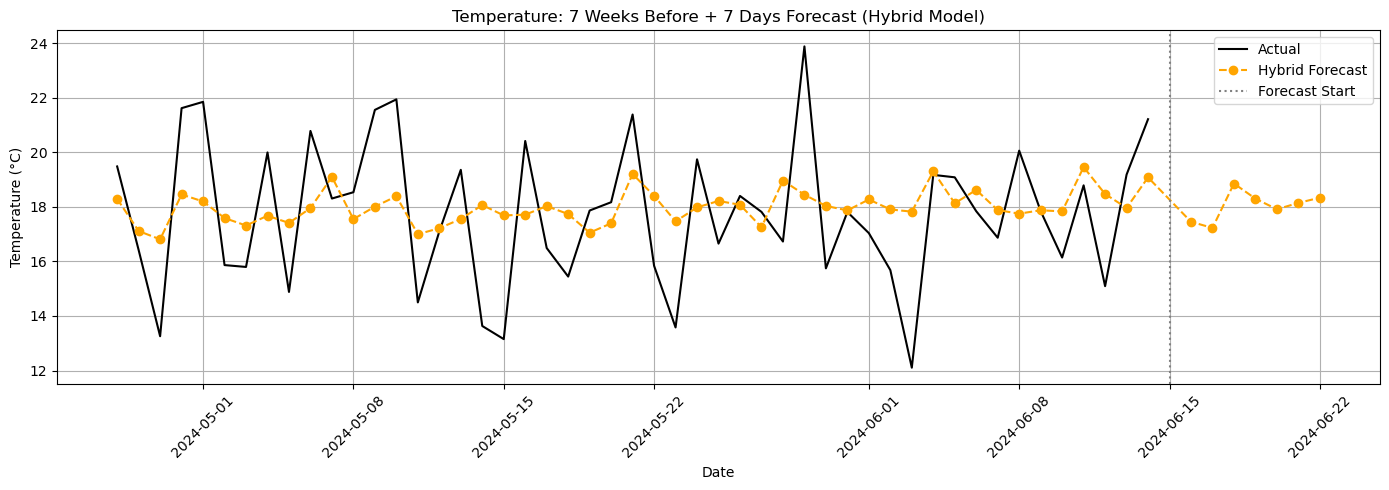

📅 Forecasted Temperatures (7-Day Ahead):
          ds  forecast_temp
0 2024-06-16      17.454104
1 2024-06-17      17.229604
2 2024-06-18      18.857121
3 2024-06-19      18.302716
4 2024-06-20      17.913111
5 2024-06-21      18.146822
6 2024-06-22      18.337949


In [23]:
# Plot graph
plt.figure(figsize=(14, 5))
plt.plot(combined_display['ds'], combined_display['actual_temp'], label='Actual', color='black')
plt.plot(combined_display['ds'], combined_display['forecast_temp'], linestyle='--', marker='o', color='orange', label='Hybrid Forecast')

# After June 15 is forecasting the temperature
plt.axvline(pd.to_datetime("2024-06-15"), color='gray', linestyle=':', label='Forecast Start')

plt.title("Temperature: 7 Weeks Before + 7 Days Forecast (Hybrid Model)")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Print results
print("📅 Forecasted Temperatures (7-Day Ahead):")
print(forecast_7[['ds', 'forecast_temp']])